# Platinum hedge — experiment lab

**Purpose: a place to experiment with the walk-forward hedge.** Change the parameter panel,
re-run, and study one trade — or a short walk-forward — end to end: *calibrate the stochastic
models on the corrected archive → strike the swap → train the day-1 policy in that simulated
world → roll the frozen policy day-by-day along the realized path.*

This notebook reuses the **end-user scripts** `production_walk_forward` and `production_solver`
as modules (they are not `riskflow` internals — they only ever call the public
`load_json` / `run_job` contract). Everything runs at **smoke fidelity** so the executed
notebook is fast; the last section documents how to scale up on a bigger GPU.

## 1. Parameters & setup

Import the public surface and the two end-user driver modules, pin GPU 0, and assert we grabbed the repo `riskflow` (not the shadow snapshot). Then the parameter panel.

In [1]:
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')   # pin GPU0 before CUDA init (GPU1 may be busy)

import json, copy, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import riskflow as rf
assert 'PycharmProjects' in rf.__file__, f"shadow-import trap — got {rf.__file__}"

# End-user driver modules (NOT riskflow internals — they only use load_json / run_job).
import production_walk_forward as pwf
from production_solver import apply_config, run

print('riskflow :', rf.__file__)
print('pwf      :', pwf.__file__)
print('device   :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')

riskflow : /home/vretiel/PycharmProjects/riskflow/riskflow/__init__.py
pwf      : /home/vretiel/PycharmProjects/riskflow/production_walk_forward.py
device   : NVIDIA GeForce RTX 3090


In [2]:
# ---- parameter panel -------------------------------------------------------------------------
# PRODUCTION defaults (what the shipping walk-forward uses). Full decision window (T_MIN=0),
# 8k-ish outer paths, 40 fit iters, 9 grid levels, 64 inner draws. BATCH scales ~linearly in GPU
# memory (peak ~8 GB at 8192x64) — it is the main big-server knob. See section 6.
PARAMS = dict(
    MONTH          = '2024-06',   # trade month (YYYY-MM); must sit inside the archive with room to roll
    SEED           = 7,
    BATCH          = 2048,        # outer training paths  (memory ~ linear in BATCH)
    FIT_ITERS      = 40,          # twin-loss fit iters per decision step
    HUBER_AVERSION = 6.0,         # AsymmetricUtility_Huber downside aversion
    LEVELS         = 9,           # action-grid levels per hedge axis
    INNER          = 64,          # inner-MC draws (the selection floor on near-identical legs)
    T_MIN          = 0,           # 0 = full day-1 window (production)
)

# SMOKE overrides so the executed notebook runs in minutes. Training is CPU-bound on the number
# of decision steps, so the big speed lever is T_MIN (a shallower window ~= the last ~45 days) —
# NOT batch/levels/inner. A smoke policy is deliberately under-trained: expect greedy ~ no-hedge
# (production fidelity is where greedy wins — see the shipping validation notebook).
SMOKE = dict(PARAMS, BATCH=512, FIT_ITERS=10, LEVELS=5, INNER=16, T_MIN=60)
# Even lighter profile for the 3-month loop in section 5 (keeps the whole notebook a few minutes).
SMOKE5 = dict(SMOKE, BATCH=256, FIT_ITERS=5)

MONTHS_3 = ['2024-04', '2024-05', '2024-06']   # the mini walk-forward in section 5
VOLUME, MARGIN = 2500.0, 8.0                    # swap size (oz) and dealer margin ($/oz)
print('SMOKE :', SMOKE)
print('SMOKE5:', SMOKE5)

SMOKE : {'MONTH': '2024-06', 'SEED': 7, 'BATCH': 512, 'FIT_ITERS': 10, 'HUBER_AVERSION': 6.0, 'LEVELS': 5, 'INNER': 16, 'T_MIN': 60}
SMOKE5: {'MONTH': '2024-06', 'SEED': 7, 'BATCH': 256, 'FIT_ITERS': 5, 'HUBER_AVERSION': 6.0, 'LEVELS': 5, 'INNER': 16, 'T_MIN': 60}


## 2. One-trade harness

`run_trade(month, params)` composes the `production_walk_forward` building blocks for a single
month: `build_corrected_archive` (done once below), a cached `calibrate` step, `build_deal_config`,
then `production_solver.apply_config` + `run` to **train** the policy and **roll** it along the
realized path. It returns the recorded row (greedy / no-hedge $/oz, causal bound, PASS) plus the
raw train / roll diagnostics and the saved checkpoint path.

In [3]:
RUN_DIR = os.path.abspath(os.path.join('artifacts', 'lab_runs',
                                        time.strftime('%Y%m%d_%H%M%S')))
os.makedirs(RUN_DIR, exist_ok=True)
print('run dir:', RUN_DIR)

# --- one-time corrected calibration inputs (mirrors production_walk_forward.main) ---
raw = pd.read_csv('data/pl_exp.csv', index_col=0, parse_dates=True)
arch = pwf.build_corrected_archive(raw)                       # decompose the raw futures archive
template = json.load(open('tests/fixtures/policy_test_simulate_only.json'))  # deal template (never edited)

arch_csv = os.path.join(RUN_DIR, 'archive_cme.csv')
arch.drop(columns=[pwf.LME_COL]).to_csv(arch_csv)             # calibration CSV drops the composed LBMA leg
md_src = json.load(open('data/MarketDataRF_platinum.json'))
md_src['MarketData']['Model Configuration']['.ModelParams']['modelfilters'] = {
    'CommodityPrice': [[['ID', 'PLATINUM_LME'], 'BasisComposedSpotModel']]}
md_cal = os.path.join(RUN_DIR, 'marketdata_corrected.json'); json.dump(md_src, open(md_cal, 'w'), indent=1)
cal_src = json.load(open('artifacts/calibration_config.json'))
cal_src['CalibrationConfig']['MarketDataArchiveFile']['name'] = arch_csv
cal_cfg = os.path.join(RUN_DIR, 'calibration_config.json'); json.dump(cal_src, open(cal_cfg, 'w'), indent=1)
print('archive:', arch.index.min().date(), '->', arch.index.max().date(), '|', len(arch), 'rows')

run dir: /home/vretiel/PycharmProjects/riskflow/artifacts/lab_runs/20260714_093800


archive: 2009-11-10 -> 2025-12-30 | 3856 rows


In [4]:
_CAL_CACHE = {}
def calibrated_md(cal_end):
    """Calibrate the corrected models on the archive up to cal_end (cached; no lookahead)."""
    if cal_end not in _CAL_CACHE:
        out = os.path.join(RUN_DIR, f'md_{cal_end}.json')
        pwf.calibrate(md_cal, cal_cfg, cal_end, out)          # subprocess -> calibrate_platinum.py
        # standing E[dF|b] guard: dP~b slope ~ 0 (martingale), dS~b < 0 (LBMA catch-up)
        g = pwf.guard_e_df_b(arch, cal_end)
        print(f'  GUARD {cal_end}: dP~b t={g["dP~b"][1]:+.2f}  dS~b t={g["dS~b"][1]:+.2f}')
        _CAL_CACHE[cal_end] = out
    return _CAL_CACHE[cal_end]


def run_trade(month, p):
    """Calibrate -> strike -> train -> roll one month. Returns row + diagnostics + checkpoint."""
    trade_date = (pd.Timestamp(month + '-01') + pd.offsets.BDay(0)).normalize()
    tag = trade_date.strftime('%Y%m')
    md = calibrated_md(trade_date.strftime('%Y-%m-%d'))
    cfg, info = pwf.build_deal_config(template, arch, trade_date, md, MARGIN, VOLUME)
    ckpt = os.path.join(RUN_DIR, f'value_fn_{tag}.pt')

    # TRAIN — production_solver best config, with the panel overrides applied on the loaded dict.
    train = apply_config(copy.deepcopy(cfg), batch=p['BATCH'], seed=p['SEED'], save=ckpt)
    ts = train['Calc']['Calculation']['Hedging_Problem']['Solver']
    ts['DiffV2_Fit_Iters'] = p['FIT_ITERS']
    ts['Training_Action_Grid_Levels_Per_Axis'] = p['LEVELS']
    ts['T_Min'] = p['T_MIN']
    train['Calc']['Calculation']['Inner_Sub_Batch'] = p['INNER']
    train['Calc']['Calculation']['Hedging_Problem']['Objective']['Huber_Aversion'] = p['HUBER_AVERSION']
    tdiag = run(train, f'train_{tag}')

    # ROLL — freeze the policy and step it day-by-day along the realized (observed) path.
    obs = os.path.join(RUN_DIR, f'obs_{tag}.npz'); pwf.observed_scenario_npz(arch, trade_date, obs)
    roll = apply_config(copy.deepcopy(cfg), batch=1, seed=p['SEED'], load=[ckpt],
                        stepper_rollout=True, randomize_initial_state=False)
    roll['Calc']['Calculation']['Hedging_Problem']['Solver']['T_Min'] = p['T_MIN']   # match the checkpoint
    roll['Calc']['Calculation']['Observed_Scenario'] = obs
    rdiag = run(roll, f'roll_{tag}')

    sv = rdiag.get('stepper_verdict') or {}
    gr = (sv.get('greedy') or {}).get('wT_mean'); nh = (sv.get('nohedge') or {}).get('wT_mean')
    bound = pwf.pf_bound(arch, trade_date, info['mats'], info['pay'])
    tv = (tdiag.get('verdict') or {}).get('greedy') or {}
    q = np.array(sv.get('greedy_q_traj') or [[0.0]])
    row = {'trade': tag, 'fair': round(info['k_fair'], 2), 'strike': round(info['k_fair'] - MARGIN, 2),
           'train_u': None if tv.get('u_mean') is None else round(tv['u_mean'], 4), 'V_0': tdiag.get('V_0'),
           'greedy_$/oz': None if gr is None else round(gr / VOLUME, 2),
           'nohedge_$/oz': None if nh is None else round(nh / VOLUME, 2),
           'pf_bound': round(bound, 2),
           'bound_pass': None if (gr is None or nh is None) else bool(gr/VOLUME <= nh/VOLUME + bound + 1e-6),
           'churn': round(float(np.abs(np.diff(q, axis=0)).sum()), 1)}
    return {'row': row, 'tdiag': tdiag, 'rdiag': rdiag, 'ckpt': ckpt,
            'cfg': cfg, 'info': info, 'trade_date': trade_date}


def realized_forward_marks(trade_date, mats, n):
    """Reconstruct the realized CME forward mark per hedge over the last n decision days
    (numpy, archive only — the same forward formula the causal bound uses). Used to draw the
    running greedy hedge MTM, which the stepper_verdict surface does not expose per step."""
    bdays = pd.bdate_range(trade_date, mats[-1])
    sub = arch.reindex(arch.index.union(bdays)).ffill().loc[bdays]
    sofr = sorted((float(c.split(',')[1]), c) for c in arch.columns if c.startswith(pwf.SOFR_PREFIX))
    cols = {}
    for j, mat in enumerate(mats, 1):
        tau = np.array([(mat - d).days for d in bdays]) / 365.25
        ct = np.array([np.interp(tt, [sub[f'Tenor.PLATINUM_TAU{k}'].iloc[i] for k in (1, 2, 3)],
                                 [sub[f'{pwf.CARRY_COL},PLATINUM_TAU{k}'].iloc[i] for k in (1, 2, 3)])
                       for i, tt in enumerate(tau)])
        rt = np.array([np.interp(tt, [t for t, _ in sofr], [sub[c].iloc[i] for _, c in sofr])
                       for i, tt in enumerate(tau)])
        F = sub[pwf.CME_COL].to_numpy() * np.exp((ct + rt) * np.clip(tau, 0, None))
        cols[f'PL_M{j}'] = np.where(tau > 0, F, np.nan)
    return pd.DataFrame(cols, index=bdays).iloc[-(n + 1):]     # n+1 marks -> n MTM deltas

## 3. Run one trade at smoke fidelity

Train + roll the panel's `MONTH` at `SMOKE` fidelity. The row shows the fair strike, the trained
utility, the realized greedy vs no-hedge P&L ($/oz), the portfolio causal bound and the
bound-PASS check. Then two diagnostics off the roll: the per-day greedy book per instrument
(`stepper_verdict['greedy_q_traj']`) and the running greedy hedge MTM reconstructed along the
realized path.

In [5]:
t0 = time.time()
res = run_trade(PARAMS['MONTH'], SMOKE)
print(f'run_trade elapsed {time.time() - t0:.0f}s')
display(pd.DataFrame([res['row']]))

INFO root === CALIBRATE through 2024-06-03 ===


WARNING md_2024-06-03 Price Factor 'DiscountRate.USD-SOFR' not found in market data


INFO md_2024-06-03 Creating default Discount Factor(type='DiscountRate', name=('USD-SOFR',))


  GUARD 2024-06-03: dP~b t=-1.54  dS~b t=-53.89


INFO PLAT_JUL29 liability scalars: total_leg_volume=2500.0 last_settlement_index=153


...

INFO PLAT_JUL29 DiffSolverV2 VERDICT (OUT-OF-SAMPLE rollout t=60→T over 1 outer paths, start flat):
  policy    u(W_T)mean    W_T mean       W_T p5         W_T CVaR5
  greedy    -1.26048    -2.5627e+05   -2.5627e+05   -2.5627e+05
  textbook  -0.68538    -1.7738e+05   -1.7738e+05   -1.7738e+05
  nohedge   -0.68538    -1.7738e+05   -1.7738e+05   -1.7738e+05
  → on the OBJECTIVE E[u(W_T)]: beats no-hedge=False, beats textbook=False | tail(CVaR5) competitive w/ textbook=False


INFO PLAT_JUL29 DiffSolverV2 greedy positions: mean|q| per instrument=['0.00', '0.00', '44.43'] | q@t0=[0.0, 0.0, -50.0] | q@mid=[0.0, 0.0, -50.0] (textbook q@t0=[0.0, 0.0, 0.0])


INFO PLAT_JUL29 solve_hedge tracks: {'DiffSolverV2': -0.5962} | ladder holds=True


run_trade elapsed 141s


,trade,fair,strike,train_u,V_0,greedy_$/oz,nohedge_$/oz,pf_bound,bound_pass,churn
0,202406,1044.23,1036.23,-1.5582,-0.596179,-122.27,-69.85,634.98,True,200.0


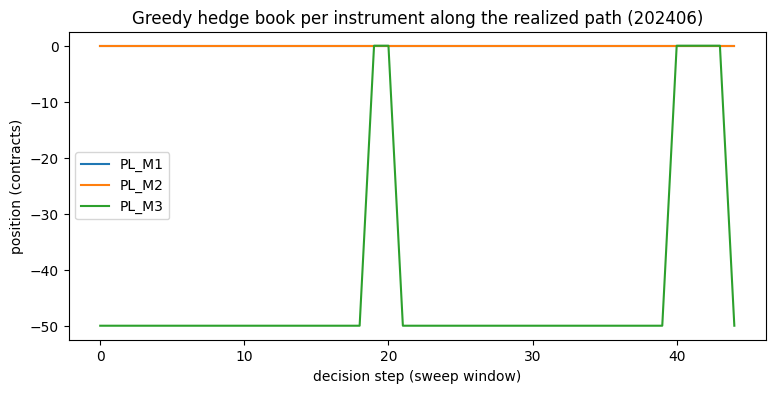

In [6]:
# --- per-day greedy positions per instrument (from the roll diagnostics' q trajectory) ---
q = np.array(res['rdiag']['stepper_verdict']['greedy_q_traj'])   # (n_decision_steps, 3)
hedges = ['PL_M1', 'PL_M2', 'PL_M3']
fig, ax = plt.subplots(figsize=(9, 4))
for j, h in enumerate(hedges):
    ax.plot(q[:, j], label=h)
ax.set_title(f'Greedy hedge book per instrument along the realized path ({res["row"]["trade"]})')
ax.set_xlabel('decision step (sweep window)')
ax.set_ylabel('position (contracts)')
ax.legend()
plt.show()

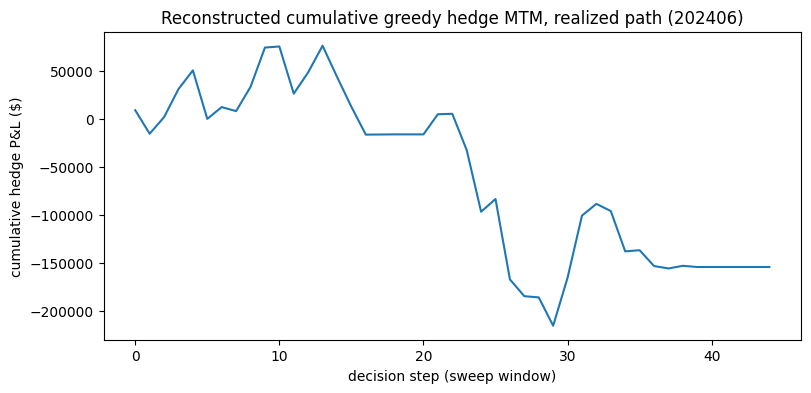

terminal reconstructed hedge MTM: $-154,124


In [7]:
# --- running greedy hedge MTM reconstructed on the realized path (numpy) ---
marks = realized_forward_marks(res['trade_date'], res['info']['mats'], q.shape[0])
cs = pwf.CONTRACT_SIZE
dF = np.diff(marks.to_numpy(), axis=0)                          # (n, 3) realized forward moves
cum = np.cumsum(np.nansum(q * cs * np.nan_to_num(dF), axis=1))  # cumulative variation-margin P&L
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cum)
ax.set_title(f'Reconstructed cumulative greedy hedge MTM, realized path ({res["row"]["trade"]})')
ax.set_xlabel('decision step (sweep window)')
ax.set_ylabel('cumulative hedge P&L ($)')
plt.show()
print('terminal reconstructed hedge MTM: ${:,.0f}'.format(float(cum[-1])))

## 4. Artifact workflow — deploy without retraining

The training step already persisted the fitted value function to `res['ckpt']` (the same
JSON-serialisable artifact `solve()` returns as `policy_artifact`). Reload it, inspect the
contract, then **re-evaluate it frozen on fresh paths** via `DiffV2_Load_Value_Fn` (a different
seed, no training). This is the deploy-without-retraining pattern: calibrate & train once, ship
the checkpoint, score it daily.

In [8]:
artifact = torch.load(res['ckpt'], map_location='cpu', weights_only=False)
print('checkpoint (persisted policy artifact) keys:')
print('  ', sorted(artifact.keys()))
print('solver_version :', artifact['solver_version'])
print('config_hash    :', artifact['config_hash'])
print('V_0 (trained)  :', artifact['V_0'])
print('hedges / active:', artifact['hedges'], artifact['active_hedge_indices'])

checkpoint (persisted policy artifact) keys:
   ['T_dec', 'V_0', 'a_bounds', 'active_hedge_indices', 'config_hash', 'hedges', 'hidden', 'm_mean', 'm_std', 'max_abs_Y_boot', 'md', 'n_star_0', 'solver_version', 'state_dicts', 't_min', 'utility_scale', 'w_mean', 'w_std']
solver_version : diffsolverv2/2026-07
config_hash    : cc6978c14c26b4098c821ccda3ef2d4f9c9ddb2d
V_0 (trained)  : -0.5961785912513733
hedges / active: ['PL_M1', 'PL_M2', 'PL_M3'] [0, 1, 2]


In [9]:
# Re-evaluate the frozen checkpoint on FRESH paths (seed+1, no training).
eval_cfg = apply_config(copy.deepcopy(res['cfg']), batch=SMOKE['BATCH'], seed=SMOKE['SEED'] + 1,
                        load=[res['ckpt']], randomize_initial_state=False)
eval_cfg['Calc']['Calculation']['Hedging_Problem']['Solver']['T_Min'] = SMOKE['T_MIN']
ediag = run(eval_cfg, 'frozen_eval')
v = ediag['verdict']
rows = [{'policy': p, 'u_mean': round(v[p]['u_mean'], 4), 'E[W_T]': round(v[p]['wT_mean'], 0),
         'wT_p5': round(v[p]['wT_p5'], 0), 'wT_cvar5': round(v[p]['wT_cvar5'], 0)}
        for p in ('greedy', 'textbook', 'nohedge')]
print('FROZEN policy re-evaluated on fresh paths (seed', SMOKE['SEED'] + 1, '):')
display(pd.DataFrame(rows))
print('V_0 on fresh eval:', ediag.get('V_0'))

WARNING md_2024-06-03 Price Factor 'DiscountRate.USD-SOFR' not found in market data


INFO md_2024-06-03 Creating default Discount Factor(type='DiscountRate', name=('USD-SOFR',))


INFO PLAT_JUL29 liability scalars: total_leg_volume=2500.0 last_settlement_index=153


INFO PLAT_JUL29 utility_scale (symlog c) resolved to 425156.83


INFO PLAT_JUL29 DiffSolverV2 setup: n_hedge=3 active=[0, 1, 2] T_dec=124 (of 126 sim steps; last-live mtm=[-2]) B_outer=512 levels=9 fit_iters=60 lr=0.002 | contract_size=[50.0, 50.0, 50.0] | q∈[[-50.0, -50.0, -50.0], [0.0, 0.0, 0.0]] total_abs_limit=50


...

INFO PLAT_JUL29 DiffSolverV2 greedy positions: mean|q| per instrument=['0.00', '0.59', '27.79'] | q@t0=[0.0, -0.48828125, -28.64990234375] | q@mid=[0.0, -0.830078125, -28.1982421875] (textbook q@t0=[0.0, -7.04111909866333, -6.948103904724121])


INFO PLAT_JUL29 solve_hedge tracks: {'DiffSolverV2': -0.5962} | ladder holds=True


FROZEN policy re-evaluated on fresh paths (seed 8 ):


,policy,u_mean,E[W_T],wT_p5,wT_cvar5
0,greedy,-0.7389,-51535.0,-485057.0,-623939.0
1,textbook,-0.7879,-59240.0,-492525.0,-645286.0
2,nohedge,-0.9178,-64744.0,-540498.0,-691349.0


V_0 on fresh eval: -0.5961785912513733


## 5. Mini walk-forward

Loop `run_trade` over three consecutive months at smoke fidelity and assemble the table, then
bar-chart the realized greedy vs no-hedge P&L per month with the portfolio causal bound annotated
(greedy must stay within `nohedge + bound`). At smoke fidelity the policy is under-trained, so
greedy will not beat no-hedge here — the point is to exercise the full calibrate→train→roll loop
month over month.

In [10]:
wf_rows = []
for m in MONTHS_3:
    r = run_trade(m, SMOKE5)
    wf_rows.append(r['row'])
    print(f"  {m}: greedy={r['row']['greedy_$/oz']}  nohedge={r['row']['nohedge_$/oz']} $/oz  "
          f"bound={r['row']['pf_bound']}  PASS={r['row']['bound_pass']}")
wf = pd.DataFrame(wf_rows)
display(wf)

INFO PLAT_JUL29 === CALIBRATE through 2024-04-01 ===


  GUARD 2024-04-01: dP~b t=-1.54  dS~b t=-53.65


WARNING md_2024-04-01 Price Factor 'DiscountRate.USD-SOFR' not found in market data


INFO md_2024-04-01 Creating default Discount Factor(type='DiscountRate', name=('USD-SOFR',))


INFO PLAT_JUL29 liability scalars: total_leg_volume=2500.0 last_settlement_index=155


...

INFO PLAT_JUL29 DiffSolverV2 VERDICT (OUT-OF-SAMPLE rollout t=60→T over 1 outer paths, start flat):
  policy    u(W_T)mean    W_T mean       W_T p5         W_T CVaR5
  greedy    -1.19928    -2.5627e+05   -2.5627e+05   -2.5627e+05
  textbook  -0.65370    -1.7738e+05   -1.7738e+05   -1.7738e+05
  nohedge   -0.65370    -1.7738e+05   -1.7738e+05   -1.7738e+05
  → on the OBJECTIVE E[u(W_T)]: beats no-hedge=False, beats textbook=False | tail(CVaR5) competitive w/ textbook=False


INFO PLAT_JUL29 DiffSolverV2 greedy positions: mean|q| per instrument=['0.00', '0.00', '44.43'] | q@t0=[0.0, 0.0, -50.0] | q@mid=[0.0, 0.0, -50.0] (textbook q@t0=[0.0, 0.0, 0.0])


INFO PLAT_JUL29 solve_hedge tracks: {'DiffSolverV2': -0.9554} | ladder holds=True


  2024-06: greedy=-122.27  nohedge=-69.85 $/oz  bound=634.98  PASS=True


,trade,fair,strike,train_u,V_0,greedy_$/oz,nohedge_$/oz,pf_bound,bound_pass,churn
0,202404,916.71,908.71,-1.9063,-1.093439,181.62,72.12,617.30,True,200.0
1,202405,952.63,944.63,-1.3335,-0.890115,86.80,1.44,619.81,True,350.0
2,202406,1044.23,1036.23,-1.9433,-0.955358,-122.27,-69.85,634.98,True,200.0


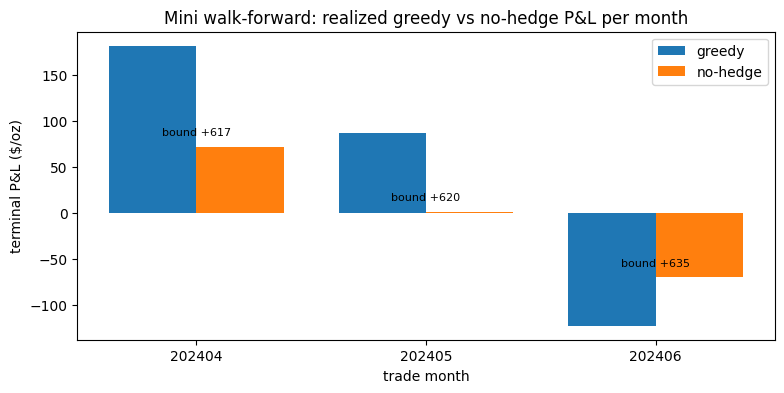

In [11]:
x = np.arange(len(wf)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, wf['greedy_$/oz'], w, label='greedy')
ax.bar(x + w/2, wf['nohedge_$/oz'], w, label='no-hedge')
for i in range(len(wf)):                                  # annotate the causal bound ceiling
    ceil = wf['nohedge_$/oz'].iloc[i] + wf['pf_bound'].iloc[i]
    ax.annotate(f"bound +{wf['pf_bound'].iloc[i]:.0f}", (x[i], wf['nohedge_$/oz'].iloc[i]),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(wf['trade'])
ax.set_title('Mini walk-forward: realized greedy vs no-hedge P&L per month')
ax.set_xlabel('trade month'); ax.set_ylabel('terminal P&L ($/oz)')
ax.legend()
plt.show()

## 6. Running on a bigger server

The recipe is identical on a larger GPU — only the panel changes. To run at production fidelity:

```python
PARAMS = dict(MONTH='2024-06', SEED=7, BATCH=8192, FIT_ITERS=40,
              HUBER_AVERSION=6.0, LEVELS=9, INNER=64, T_MIN=0)   # full day-1 window
res = run_trade(PARAMS['MONTH'], PARAMS)     # pass PARAMS directly (no SMOKE overrides)
```

**Environment**

* `export CUDA_VISIBLE_DEVICES=0` (or whichever device is free) — pin **before** the kernel
  starts so torch binds the right GPU; the notebook re-asserts it in section 1.
* Training is CPU-bound on the number of decision steps, so `T_MIN=0` (full window) is the
  slow-but-correct production setting; the batch/inner knobs mostly cost GPU memory, not wall time.

**Memory at scale** (peak, roughly linear in `BATCH` at `INNER=64`):

| BATCH  | approx peak GPU memory |
|-------:|-----------------------:|
| 2048   | ~2 GB                  |
| 8192   | ~8 GB                  |
| 16384  | ~16 GB (needs care — the recipe is validated stable to ~8192) |

For an ensemble deployment, train several seeds (`production_solver.py --seeds 7 42 314`),
then evaluate the frozen members together with `DiffV2_Load_Value_Fn=[ckpt1, ckpt2, ...]`
(ensemble argmax, cross-fit winner's-curse reduction).

**Where results land**: each run writes a fresh `artifacts/lab_runs/<timestamp>/` with the
calibrated market data, per-month checkpoints (`value_fn_<YYYYMM>.pt`), observed-path npz files,
and the calibration inputs — everything needed to reload and re-score a policy later.